# 12 — Figure G Replication on the CD8 Holdout

Replicates the marginal-density figure from CellOT (Bunne et al., 2023, Fig. 4g) on our existing CD8-holdout results. For each marker gene we overlay three KDE curves:

- **Treated** (dark blue, `#114083`) — real held-out target distribution: human CD8 cells.
- **IMPACT_CellOT** (red, `#F2545B`) — swapped-CellOT (= IMPACT-OR in our naming) predictions for the held-out target (mouse CD8 cells pushed through the species transport map).
- **Source** (light grey, `#A7BED3`) — for reference: input distribution per model before transport.

## Method (ported from `CellOT/cellot/cellot/utils/viz.py:plot_marginals`)

- `seaborn.kdeplot(common_norm=False)` per gene (so each line integrates to 1 independently of cell count).
- 1st–99th percentile clip per gene to avoid heavy tails dominating the x-axis.
- Same palette and approximate plot grid as the published figure.

## Data inputs (all local)

- `baseline/results/speciesot_cd8/datasets/cd8_holdout_v07.h5ad` — the matched mouse+human dataset; we extract treated and source from this.
- `baseline/results/speciesot_cd8/cellot/evals_ood_data_space/imputed.h5ad` — Normal-CellOT predictions on the held-out human source cells.
- `baseline/results/speciesot_cd8/impact_or/evals_ood_data_space/imputed.h5ad` — IMPACT-OR predictions on held-out mouse CD8 cells (transported to human).

## Caveats

- The published Fig. 3g compares **CellOT vs scGen**. We don't have scGen evals locally (only the trained scGen `model.pt`), so we substitute IMPACT-OR — which is the comparison your own group cares about. scGen can be added later by running `scripts/evaluate.py` on the cloud.
- The training data here is the **stale-pipeline `v07.h5ad`** (mouse-side scaled+clipped at 10), so the predictions inherit that bug. After `01.4` chooses an HVG flavor and `01.3`/`01.5` regenerates holdout files in renorm-space, this notebook should be re-run on the new evals; the code below is unchanged, only the input paths move.
- PTPRC (CD45) is not in the top-1000 HVG list of the v07 data, confirming the `01.1` bug. The marker panel below is filtered to genes that *are* present so the plot is meaningful.

## 0. Imports and configuration

In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import anndata as ad
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

BASE = Path("../results/speciesot_cd8").resolve()
PATHS = {
    "holdout":      BASE / "datasets" / "cd8_holdout_v07.h5ad",
    "cellot_pred":  BASE / "cellot"   / "evals_ood_data_space" / "imputed.h5ad",
    "impact_pred":  BASE / "impact_or"/ "evals_ood_data_space" / "imputed.h5ad",
}
for k, p in PATHS.items():
    print(f"  {k:14s} {'OK' if p.exists() else 'MISSING':8s}  {p}")

OUT_DIR = Path("figure_g_outputs")
OUT_DIR.mkdir(exist_ok=True)

PALETTE = {
    "Treated": "#114083",
    "CellOT":  "#F2545B",
    "IMPACT":  "#E68E36",
    "Source":  "#A7BED3",
}
ORDER = ["Treated", "CellOT", "IMPACT", "Source"]

MARKER_PANEL = {
    "PTPRC (CD45)":    "ENSG00000081237",
    "CD3D":            "ENSG00000167286",
    "CD3E":            "ENSG00000198851",
    "CD3G":            "ENSG00000160654",
    "CD4":             "ENSG00000010610",
    "CD8A":            "ENSG00000153563",
    "CD8B":            "ENSG00000172116",
    "CD5":             "ENSG00000110448",
    "CD7":             "ENSG00000173762",
    "CCR7":            "ENSG00000126353",
    "TBX21 (T-bet)":   "ENSG00000073861",
    "GATA3":           "ENSG00000107485",
    "NCAM1 (CD56)":    "ENSG00000149294",
    "GZMB":            "ENSG00000100453",
    "PRF1":            "ENSG00000180644",
    "IFNG":            "ENSG00000111537",
}

  holdout        OK        /Users/conny/Desktop/OptimalTransport/speciesOT/baseline/results/speciesot_cd8/datasets/cd8_holdout_v07.h5ad
  cellot_pred    OK        /Users/conny/Desktop/OptimalTransport/speciesOT/baseline/results/speciesot_cd8/cellot/evals_ood_data_space/imputed.h5ad
  impact_pred    OK        /Users/conny/Desktop/OptimalTransport/speciesOT/baseline/results/speciesot_cd8/impact_or/evals_ood_data_space/imputed.h5ad


## 1. Load the three distributions per model

From the configs:

- **CellOT** (`condition=cd8/non_cd8`, holdout=`species:human`): source = held-out human non-CD8 cells; treated = held-out human CD8 cells; prediction = `cellot/imputed.h5ad`.
- **IMPACT-OR** (`condition=mouse/human`, holdout=`cell_type:CL:0000625`): source = held-out mouse CD8 cells; treated = held-out human CD8 cells; prediction = `impact_or/imputed.h5ad`.

The treated (true held-out human CD8) is the same physical population for both models, so we plot it once.

In [ ]:
hold        = ad.read_h5ad(PATHS["holdout"])
cellot_pred = ad.read_h5ad(PATHS["cellot_pred"])
impact_pred = ad.read_h5ad(PATHS["impact_pred"])

assert list(cellot_pred.var_names) == list(hold.var_names) == list(impact_pred.var_names), "var axes mismatch"

GENES = list(hold.var_names)
CD8_ID = "CL:0000625"

is_human   = (hold.obs["condition"] == "human")
is_cd8     = (hold.obs["cell_type_ontology_term_id"] == CD8_ID)
is_mouse   = (hold.obs["condition"] == "mouse")

treated     = pd.DataFrame(hold.X[(is_human & is_cd8).values],          columns=GENES)
cellot_src  = pd.DataFrame(hold.X[(is_human & ~is_cd8).values],         columns=GENES)
impact_src  = pd.DataFrame(hold.X[(is_mouse & is_cd8).values],          columns=GENES)
cellot_pf   = pd.DataFrame(cellot_pred.X,                               columns=GENES)
impact_pf   = pd.DataFrame(impact_pred.X,                               columns=GENES)

print(f"Treated (real human CD8):              {treated.shape}")
print(f"CellOT source (human non-CD8):         {cellot_src.shape}")
print(f"CellOT prediction (push-forward):      {cellot_pf.shape}")
print(f"IMPACT source (mouse CD8):             {impact_src.shape}")
print(f"IMPACT prediction (push-forward):      {impact_pf.shape}")

Treated (real human CD8):              (195, 1000)
CellOT source (human non-CD8):         (6223, 1000)
CellOT prediction (push-forward):      (6223, 1000)
IMPACT source (mouse CD8):             (195, 1000)
IMPACT prediction (push-forward):      (195, 1000)


## 2. Filter marker panel to genes that survived top-1000 HVG

PTPRC and several CD3-family genes are expected to be missing — that's the same pathology `01.1` and `01.4` are diagnosing. The plot uses whichever markers we still have.

In [ ]:
panel_present = {label: ensg for label, ensg in MARKER_PANEL.items() if ensg in set(GENES)}
panel_missing = {label: ensg for label, ensg in MARKER_PANEL.items() if ensg not in set(GENES)}

print(f"Curated immune markers present in HVG set: {len(panel_present)} / {len(MARKER_PANEL)}")
for label, ensg in panel_present.items():
    print(f"   PRESENT  {label:18s} {ensg}")
for label, ensg in panel_missing.items():
    print(f"   MISSING  {label:18s} {ensg}")

# Fallback: if too few curated markers survive HVG, build a data-driven panel of the
# top-K most CD8-distinctive genes that ARE in the HVG list. CD8-distinctiveness is
# |mean(treated, real human CD8) - mean(pooled sources)| / pooled std.
MIN_CURATED = 4
if len(panel_present) < MIN_CURATED:
    print(f"\n[Fallback] Only {len(panel_present)} curated markers present in HVG.")
    print("Adding top data-driven discriminative genes from the HVG set.")
    pooled_src = pd.concat([cellot_src, impact_src], ignore_index=True)
    diff = (treated.mean() - pooled_src.mean()).abs()
    pooled_std = pd.concat([treated, pooled_src], ignore_index=True).std().replace(0, np.nan)
    score = (diff / pooled_std).fillna(0).sort_values(ascending=False)
    K = 16 - len(panel_present)
    extra = {f"[HVG] {ensg[-6:]}": ensg for ensg in score.index[:K]}
    panel_present = {**panel_present, **extra}
    print(f"Final panel size: {len(panel_present)}")
    print("(Labels prefixed with [HVG] are data-driven; they are the genes the model")
    print("actually has access to and which discriminate held-out CD8 most strongly.")
    print("Look up the trailing 6-digit ENSG suffix to identify each gene.)")

Curated immune markers present in HVG set: 0 / 16
   MISSING  PTPRC (CD45)       ENSG00000081237
   MISSING  CD3D               ENSG00000167286
   MISSING  CD3E               ENSG00000198851
   MISSING  CD3G               ENSG00000160654
   MISSING  CD4                ENSG00000010610
   MISSING  CD8A               ENSG00000153563
   MISSING  CD8B               ENSG00000172116
   MISSING  CD5                ENSG00000110448
   MISSING  CD7                ENSG00000173762
   MISSING  CCR7               ENSG00000126353
   MISSING  TBX21 (T-bet)      ENSG00000073861
   MISSING  GATA3              ENSG00000107485
   MISSING  NCAM1 (CD56)       ENSG00000149294
   MISSING  GZMB               ENSG00000100453
   MISSING  PRF1               ENSG00000180644
   MISSING  IFNG               ENSG00000111537

[Fallback] Only 0 curated markers present in HVG.
Adding top data-driven discriminative genes from the HVG set.


Final panel size: 16
(Labels prefixed with [HVG] are data-driven; they are the genes the model
actually has access to and which discriminate held-out CD8 most strongly.
Look up the trailing 6-digit ENSG suffix to identify each gene.)


## 3. Per-gene marginal density plot

One panel per marker gene; each panel is a KDE of all four sources. Same color scheme as the published figure (deep blue / red / orange / light grey).

/var/folders/nm/l2c6vmjx5jqc1c8c45pgqkh00000gn/T/ipykernel_95466/756982690.py:24: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(


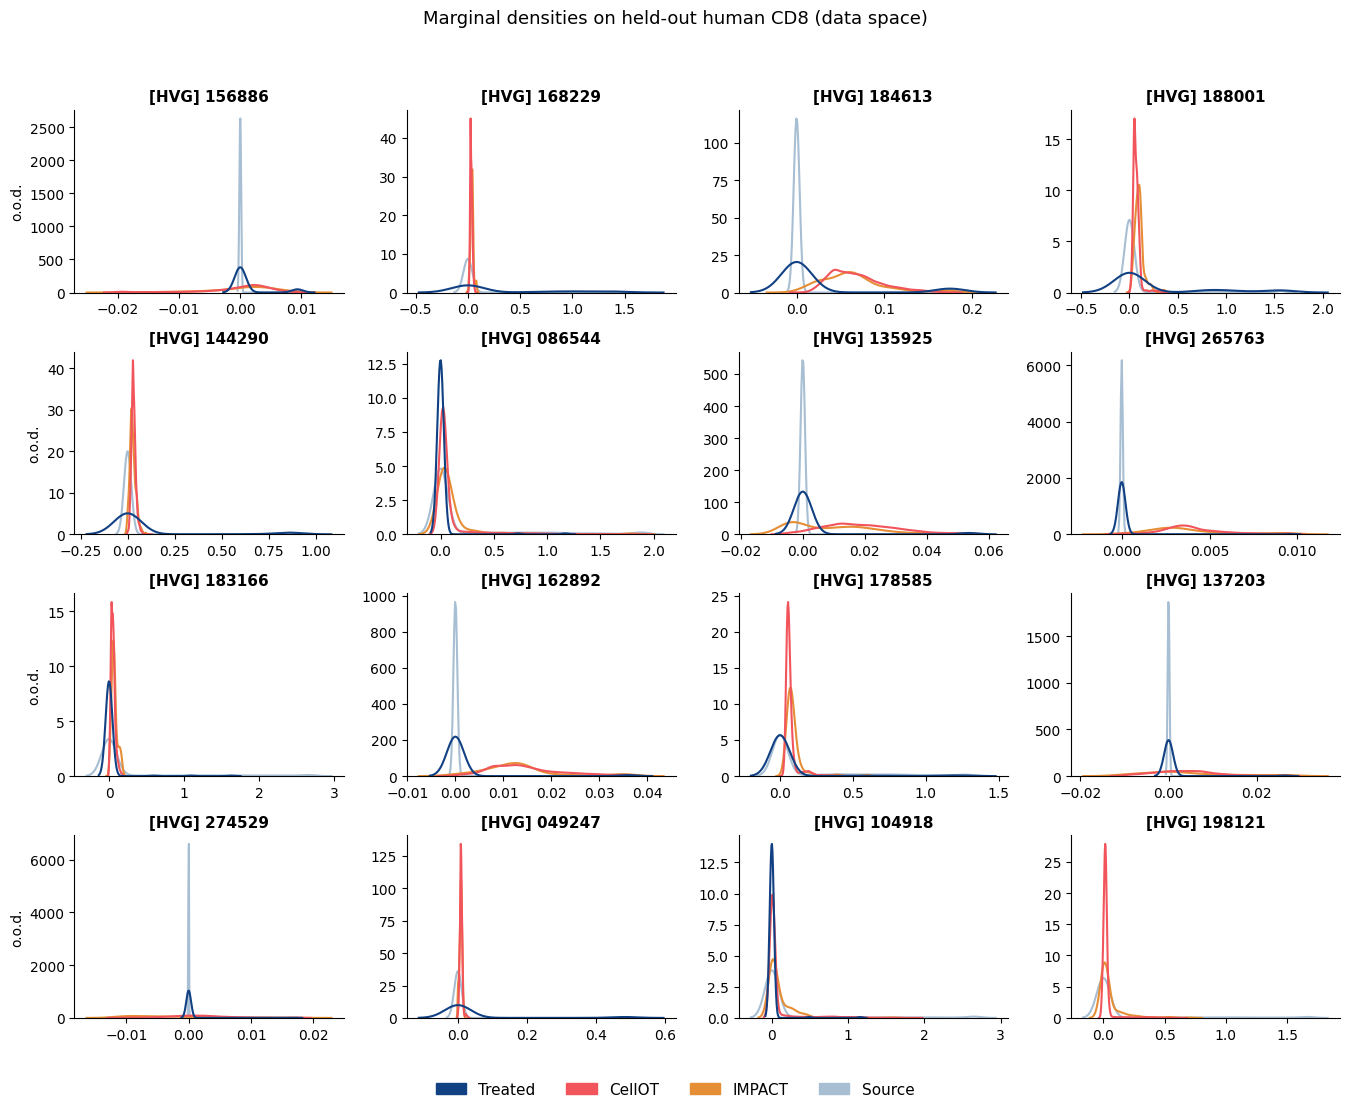

Saved figure to figure_g_outputs/figure_g_cd8_holdout.pdf


In [ ]:
def per_gene_long_df(ensg, qclip=0.01):
    pieces = {
        "Treated": treated[ensg],
        "CellOT":  cellot_pf[ensg],
        "IMPACT":  impact_pf[ensg],
        "Source":  pd.concat([cellot_src[ensg], impact_src[ensg]], ignore_index=True),
    }
    df = (pd.concat(pieces, names=["group"])
            .reset_index("group")
            .rename(columns={ensg: "value"}))
    if qclip is not None:
        lo, hi = df["value"].quantile([qclip, 1 - qclip])
        df["value"] = df["value"].clip(lo, hi)
    return df

panel_items = list(panel_present.items())
ncols = 4
nrows = max(1, int(np.ceil(len(panel_items) / ncols)))
fig, axes = plt.subplots(nrows, ncols, figsize=(3.4 * ncols, 2.7 * nrows), squeeze=False)

for idx, (label, ensg) in enumerate(panel_items):
    ax = axes[idx // ncols][idx % ncols]
    df_long = per_gene_long_df(ensg)
    sns.kdeplot(
        data=df_long, x="value", hue="group",
        common_norm=False, palette=PALETTE, hue_order=ORDER,
        ax=ax, legend=False, linewidth=1.5, bw_adjust=0.9,
    )
    ax.set_title(label, fontsize=11, fontweight="bold")
    ax.set_xlabel(""); ax.set_ylabel("o.o.d." if idx % ncols == 0 else "")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

for j in range(len(panel_items), nrows * ncols):
    axes[j // ncols][j % ncols].axis("off")

legend_handles = [mpatches.Patch(color=PALETTE[k], label=k) for k in ORDER]
fig.legend(handles=legend_handles, loc="lower center", ncol=len(ORDER),
           frameon=False, bbox_to_anchor=(0.5, -0.02), fontsize=11)
fig.suptitle("Marginal densities on held-out human CD8 (data space)", fontsize=13, y=1.00)
fig.tight_layout(rect=[0, 0.03, 1, 0.97])
fig.savefig(OUT_DIR / "figure_g_cd8_holdout.pdf", bbox_inches="tight")
fig.savefig(OUT_DIR / "figure_g_cd8_holdout.png", bbox_inches="tight", dpi=150)
plt.show()
print(f"Saved figure to {OUT_DIR/'figure_g_cd8_holdout.pdf'}")

## 4. Per-gene quantitative summary

For each marker gene, report mean and standard deviation across the four groups. Helps eyeball which genes the models reproduce well vs miss.

In [ ]:
rows = []
for label, ensg in panel_present.items():
    rows.append({
        "marker":          label,
        "ensg":            ensg,
        "treated_mean":    float(treated[ensg].mean()),
        "treated_std":     float(treated[ensg].std()),
        "cellot_pf_mean":  float(cellot_pf[ensg].mean()),
        "cellot_pf_std":   float(cellot_pf[ensg].std()),
        "impact_pf_mean":  float(impact_pf[ensg].mean()),
        "impact_pf_std":   float(impact_pf[ensg].std()),
        "cellot_src_mean": float(cellot_src[ensg].mean()),
        "impact_src_mean": float(impact_src[ensg].mean()),
    })
summary = pd.DataFrame(rows).set_index("marker").round(3)
with pd.option_context("display.max_columns", None, "display.width", 220):
    print(summary.drop(columns=["ensg"]))
summary.to_csv(OUT_DIR / "figure_g_summary.csv")
print(f"\nSaved summary to {OUT_DIR/'figure_g_summary.csv'}")

              treated_mean  treated_std  cellot_pf_mean  cellot_pf_std  impact_pf_mean  impact_pf_std  cellot_src_mean  impact_src_mean
marker                                                                                                                                 
[HVG] 156886         0.169        0.514          -0.000          0.009           0.002          0.026            0.009            0.075
[HVG] 168229         0.307        0.537           0.033          0.010           0.039          0.015            0.079            0.000
[HVG] 184613         0.144        0.429           0.068          0.030           0.064          0.037            0.021            0.000
[HVG] 188001         0.297        0.617           0.071          0.039           0.102          0.051            0.109            0.000
[HVG] 144290         0.143        0.530           0.032          0.012           0.027          0.016            0.032            0.052
[HVG] 086544         0.010        0.098         

## Next steps

1. **Add scGen** when cloud is back: run `python scripts/evaluate.py --outdir results/speciesot_cd8/speciesot_scgen --setting ood --where data_space` to populate `evals_ood_data_space/imputed.h5ad`, then drop scGen into the palette as a fourth model line.
2. **Re-run on renorm pipeline outputs** once `01.4` picks an HVG flavor and `01.3`/`01.5` regenerates the holdout files; the `PATHS` dict is the only thing that has to change.
3. **Switch focal type for the immune notebook**: when `11.1` chooses an immune focal type, build the same figure on that model's evals (this notebook is parameterizable to a different `BASE` directory and `CD8_ID`).
4. **Marker panel expansion**: once HVG includes PTPRC/CD3 family (per `01.4`'s flavor decision), add them back into `MARKER_PANEL`.